In [14]:
import pandas as pd

df = pd.read_csv("Women-Safety-AI/data/twitter_labeled.csv")

In [15]:
df.head()

,Unnamed: 0,Tweets,id,lens,date,place,coordinateS,lang,source,likes,retweets,Clean_Tweet,Sentiment
0,2,⁦@JoeManchinWV⁩ is rapist...the ⁦⁦@GOP⁩ and #m...,1390782207061544961,183,2021-05-07 21:34:52,NaN,NaN,en,Twitter for iPhone,0,0,rapistthe moscowmitch keep saying rapeculture ...,Negative
1,4,RT @JusticeOzzie: Ms Brittany Higgins : “At th...,1390780006435987456,140,2021-05-07 21:26:07,NaN,NaN,en,Twitter for Android,0,279,brittany higgins “at start meeting scott morri...,Positive
2,7,⚠️A credible source in #Tigray: #Hawzien Hospi...,1390775573006405634,316,2021-05-07 21:08:30,NaN,NaN,en,Twitter Web App,0,0,⚠️a credible source tigray hawzien hospital si...,Negative
3,8,"RT @FarazPervaiz3: @arifaajakia In Gujranwala,...",1390774257765036036,140,2021-05-07 21:03:17,NaN,NaN,en,Twitter for Android,0,1,gujranwala another christian girl kinzawas rap...,Negative
4,9,#MonaLisa‘s account of #rape is one of hundred...,1390774105700511754,275,2021-05-07 21:02:40,NaN,NaN,en,Twitter for Android,0,0,monalisa‘s account rape one hundred detailing ...,Negative


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4607 entries, 0 to 4606
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   4607 non-null   int64  
 1   Tweets       4607 non-null   object 
 2   id           4607 non-null   int64  
 3   lens         4607 non-null   int64  
 4   date         4607 non-null   object 
 5   place        21 non-null     object 
 6   coordinateS  0 non-null      float64
 7   lang         4607 non-null   object 
 8   source       4607 non-null   object 
 9   likes        4607 non-null   int64  
 10  retweets     4607 non-null   int64  
 11  Clean_Tweet  4607 non-null   object 
 12  Sentiment    4607 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 468.0+ KB


In [23]:
pip install wordcloud

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

In [17]:
df.describe(include="all")

,Unnamed: 0,Tweets,id,lens,date,place,coordinateS,lang,source,likes,retweets,Clean_Tweet,Sentiment
count,4607.000000,4607,4.607000e+03,4607.000000,4607,21,0.0,4607,4607,4607.000000,4607.000000,4607,4607
unique,NaN,1668,NaN,NaN,4582,21,NaN,1,69,NaN,NaN,1338,3
top,NaN,"b""RT @drzarni: Women of #Myanmar's message for...",NaN,NaN,2021-05-03 00:45:47,Place(_api=<tweepy.api.API object at 0x7fd4c3f...,NaN,en,Twitter for Android,NaN,NaN,woman myanmar message mal general amp sac terr...,Negative
freq,NaN,361,NaN,NaN,3,1,NaN,4607,2045,NaN,NaN,361,3439
mean,2871.748643,NaN,1.389338e+18,161.831344,NaN,NaN,NaN,NaN,NaN,1.180812,561.600391,NaN,NaN
std,1634.393609,NaN,8.021467e+14,54.470119,NaN,NaN,NaN,NaN,NaN,15.654559,2137.758022,NaN,NaN
min,2.000000,NaN,1.387959e+18,20.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
25%,1289.500000,NaN,1.388732e+18,140.000000,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,NaN,NaN
50%,3021.000000,NaN,1.389374e+18,140.000000,NaN,NaN,NaN,NaN,NaN,0.000000,17.000000,NaN,NaN
75%,4248.500000,NaN,1.390090e+18,144.000000,NaN,NaN,NaN,NaN,NaN,0.000000,221.000000,NaN,NaN


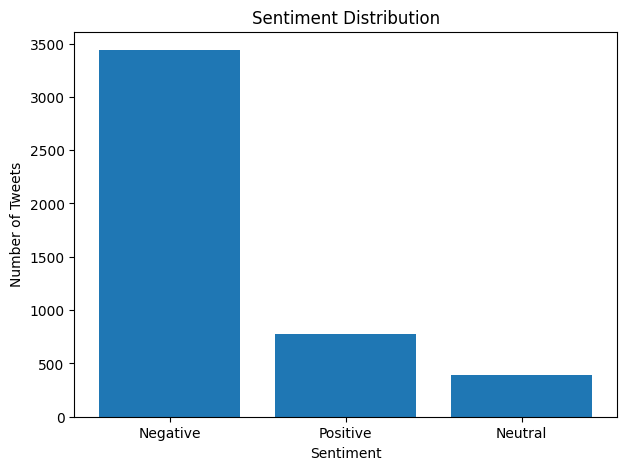

In [46]:
import matplotlib.pyplot as plt

counts = df["Sentiment"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(counts.index, counts.values)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Tweets")

plt.show()

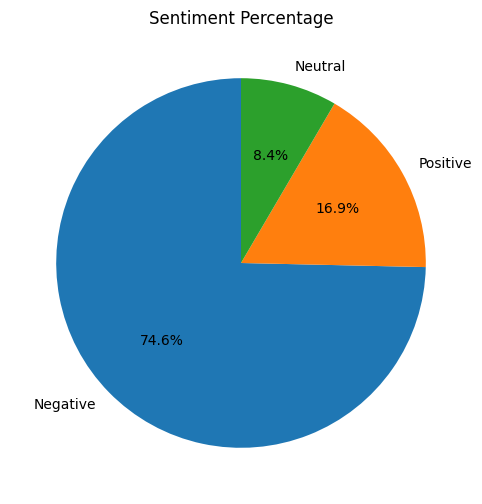

In [48]:
plt.figure(figsize=(6,6))

plt.pie(counts.values,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Sentiment Percentage")

plt.savefig("Women-Safety-AI/screenshots/Pie_Chart.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

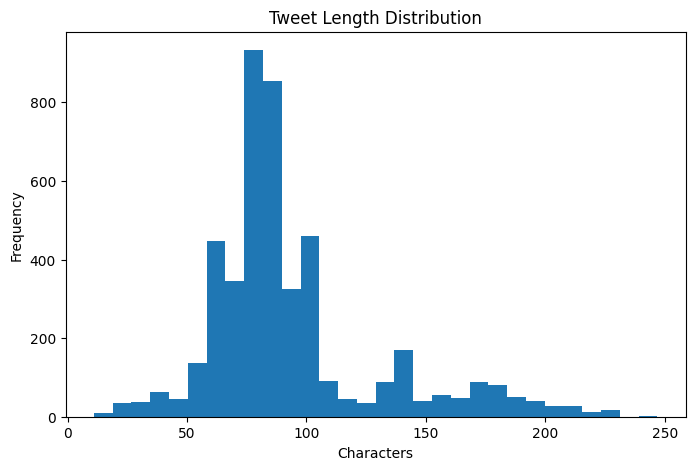

In [43]:
df["Tweet_Length"] = df["Clean_Tweet"].str.len()

plt.figure(figsize=(8,5))

plt.hist(df["Tweet_Length"], bins=30)

plt.title("Tweet Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.savefig("Women-Safety-AI/screenshots/Tweet_length.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

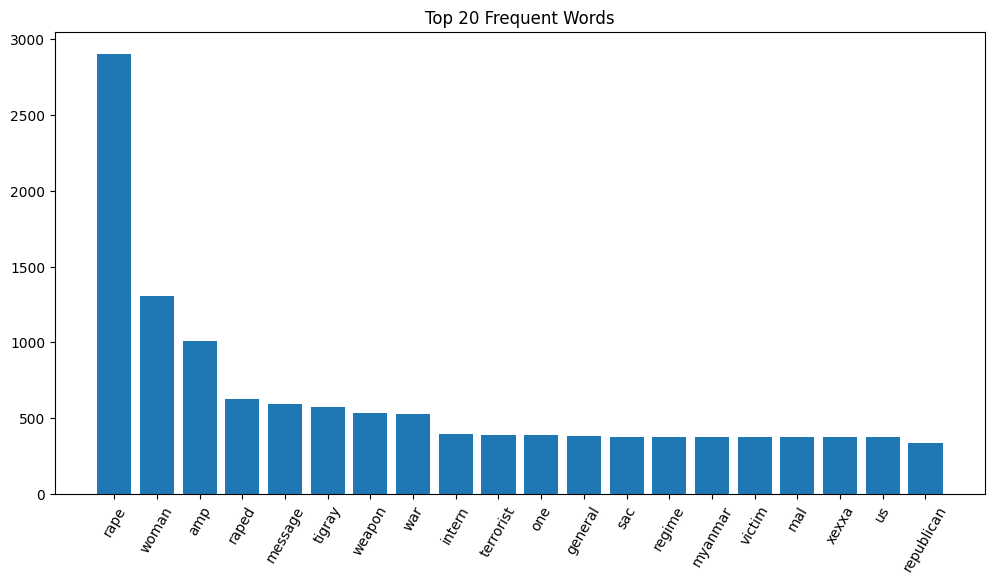

In [42]:
all_words = " ".join(df["Clean_Tweet"])

words = all_words.split()

word_counts = Counter(words)

top_words = word_counts.most_common(20)

words = [i[0] for i in top_words]

counts = [i[1] for i in top_words]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.xticks(rotation=60)

plt.title("Top 20 Frequent Words")

plt.savefig("Women-Safety-AI/screenshots/Top20.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

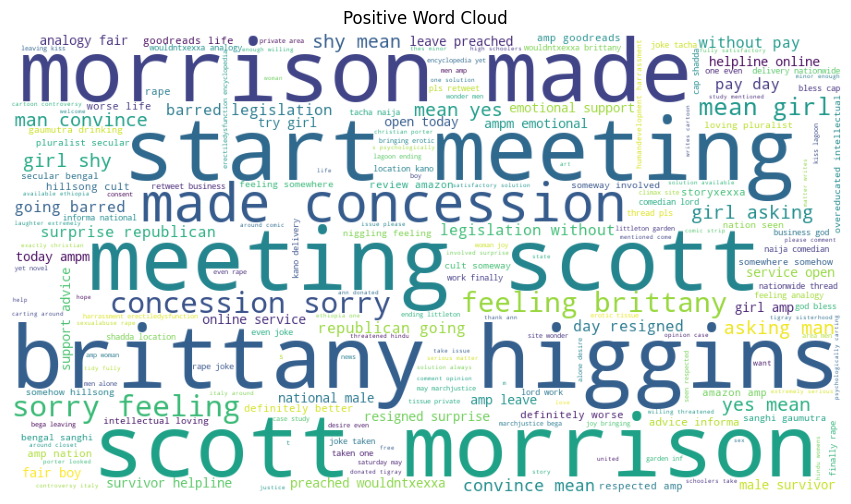

In [41]:
positive_text = " ".join(
    df[df["Sentiment"]=="Positive"]["Clean_Tweet"]
)

wc = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis("off")

plt.title("Positive Word Cloud")

plt.savefig("Women-Safety-AI/screenshotsPositive_Word.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

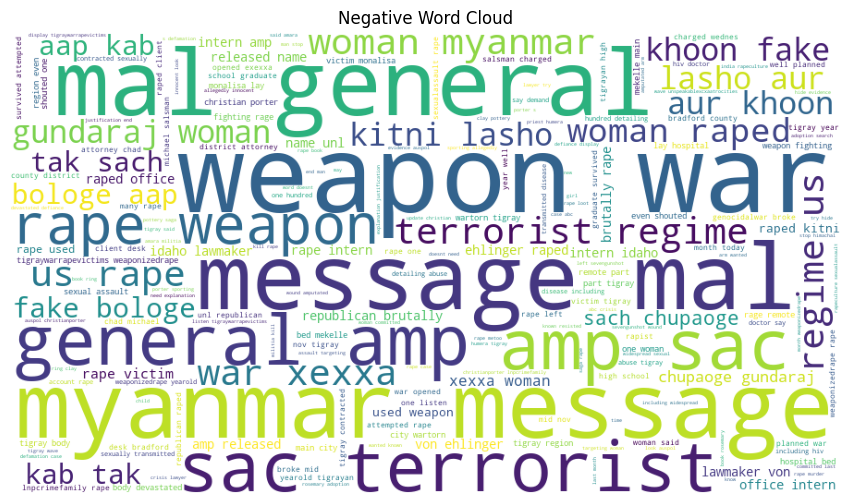

In [40]:
negative_text = " ".join(
    df[df["Sentiment"]=="Negative"]["Clean_Tweet"]
)

wc = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis("off")

plt.title("Negative Word Cloud")

plt.savefig("Women-Safety-AI/screenshots/Negative_Word.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

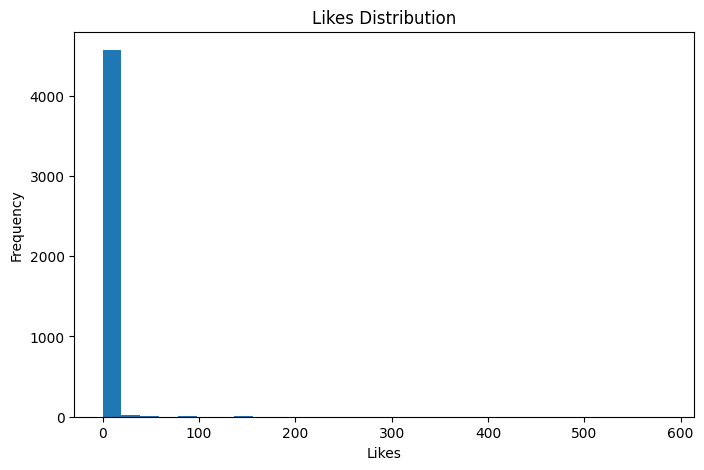

In [39]:
plt.figure(figsize=(8,5))

plt.hist(df["likes"],
         bins=30)

plt.title("Likes Distribution")

plt.xlabel("Likes")

plt.ylabel("Frequency")

plt.savefig("Women-Safety-AI/screenshots/Likes.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

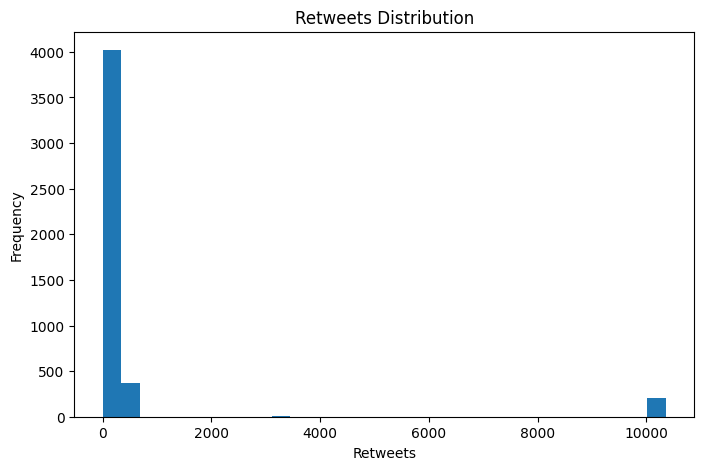

In [38]:
plt.figure(figsize=(8,5))

plt.hist(df["retweets"],
         bins=30)

plt.title("Retweets Distribution")

plt.xlabel("Retweets")

plt.ylabel("Frequency")

plt.savefig("Women-Safety-AI/screenshots/Retweets.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

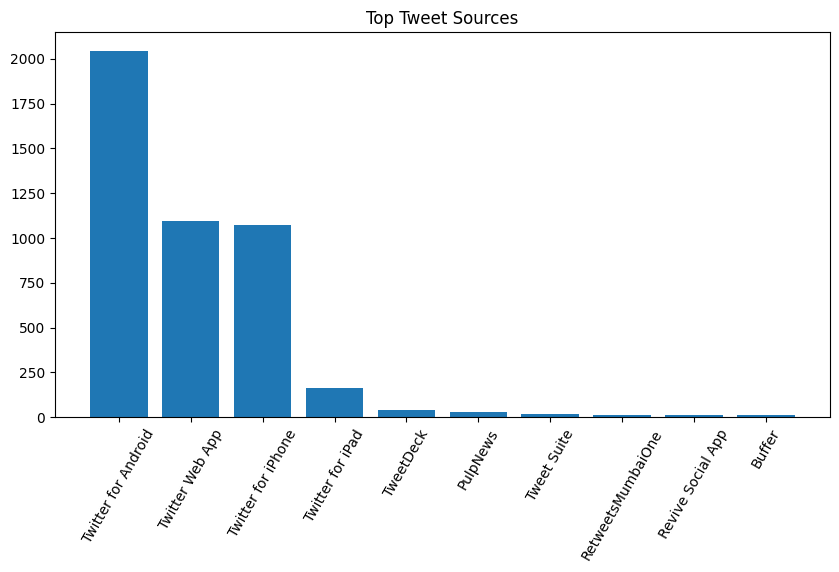

In [37]:
top = df["source"].value_counts().head(10)

plt.figure(figsize=(10,5))

plt.bar(top.index,
        top.values)

plt.xticks(rotation=60)

plt.title("Top Tweet Sources")
plt.savefig("Women-Safety-AI/screenshots/Top_Tweet.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [32]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


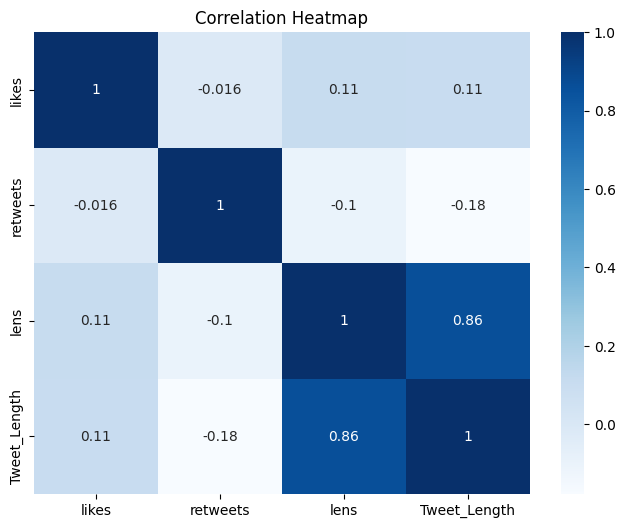

In [36]:
import seaborn as sns

numeric = df[["likes",
              "retweets",
              "lens",
              "Tweet_Length"]]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.savefig("Women-Safety-AI/screenshots/Heaptmap.png",
            dpi=300,
            bbox_inches="tight")
plt.show()